In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/Telco_Customer_Churn.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
churn = df[df["Churn"]=="Yes"]
churn.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
13,0280-XJGEX,Male,0,No,No,49,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes
18,4190-MFLUW,Female,0,Yes,Yes,10,Yes,No,DSL,No,...,Yes,Yes,No,No,Month-to-month,No,Credit card (automatic),55.20,528.35,Yes
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,No,No,Yes,Month-to-month,Yes,Electronic check,39.65,39.65,Yes
22,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
26,6467-CHFZW,Male,0,Yes,Yes,47,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.35,4749.15,Yes
27,8665-UTDHZ,Male,0,Yes,Yes,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,30.20,30.2,Yes


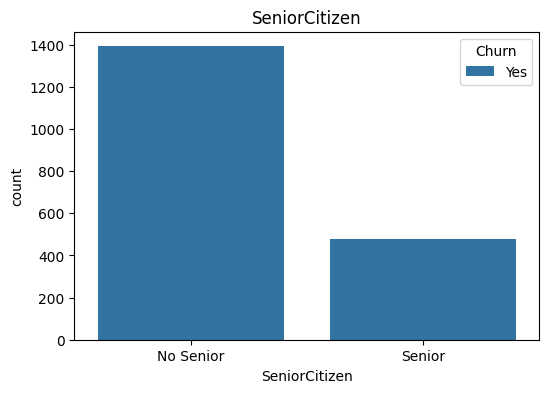

In [5]:
#Seniorcitizen

plt.figure(figsize=(6,4))

sns.countplot(data=churn, x="SeniorCitizen", hue="Churn")
plt.xticks([0,1], ["No Senior", "Senior"])
plt.title("SeniorCitizen")
plt.show()

### Analisis de seniorCitizen
Se puede observar que el mayor numero de personas que cancelaron el servicio eran menores de edad, con esto podemos deducir que el problema viene por el capital, pero tendríamos que analizar el monto mensual

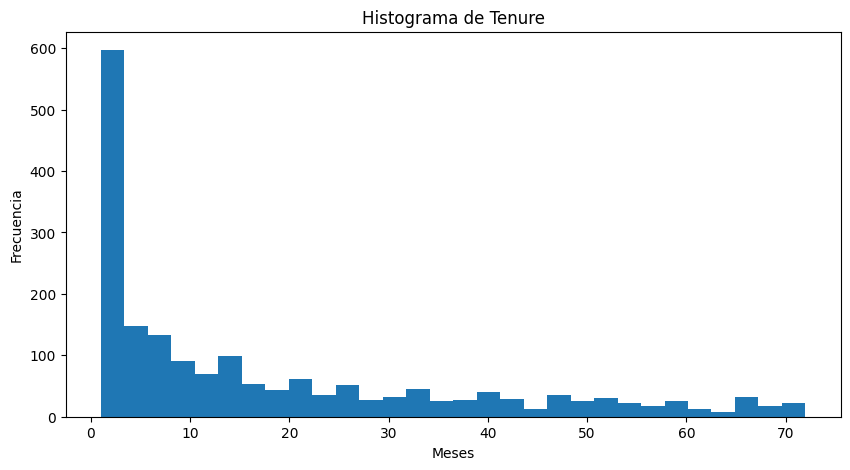

In [6]:
#Tenure
plt.figure(figsize=(10,5))
plt.hist(churn["tenure"], bins=30)

plt.title("Histograma de Tenure")
plt.xlabel("Meses")
plt.ylabel("Frecuencia")

plt.show()

### Analisis de Tenure
Se puede observar que el mayor numero de personas que cancelaron el servicio fueron en los primeros meses, entre más tardó el cliente con el servicio menos probabilidad de que cancele su contrato


In [7]:
#Contract
churn["Contract"].unique()

<StringArray>
['Month-to-month', 'Two year', 'One year']
Length: 3, dtype: str

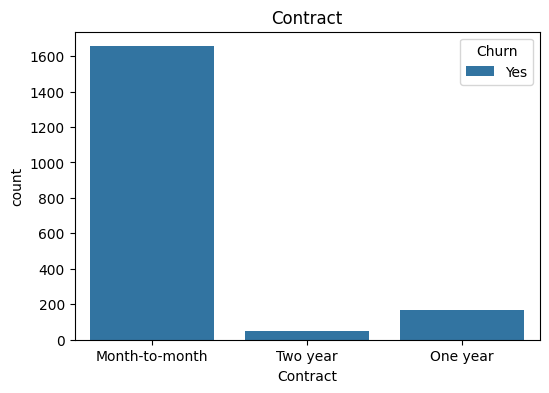

In [8]:
#Contract
plt.figure(figsize=(6,4))

sns.countplot(data=churn, x="Contract", hue="Churn")
plt.title("Contract")
plt.show()

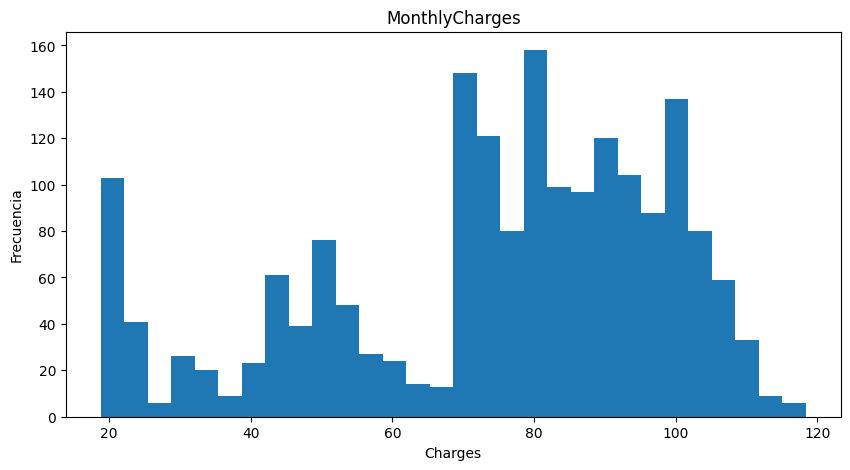

In [9]:
#MonthlyCharges
plt.figure(figsize=(10,5))
plt.hist(churn["MonthlyCharges"], bins=30)

plt.title("MonthlyCharges")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")

plt.show()

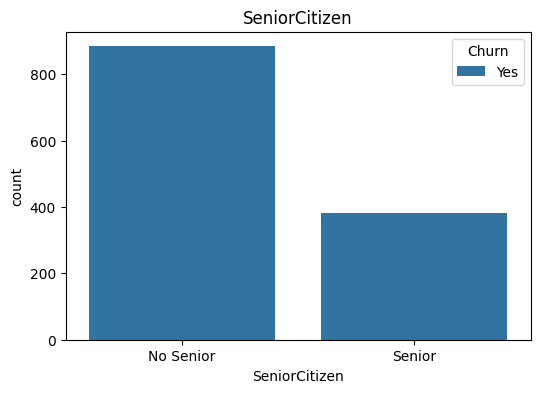

In [11]:
monthly = churn[churn["MonthlyCharges"]>70]
plt.figure(figsize=(6,4))

sns.countplot(data=monthly, x="SeniorCitizen", hue="Churn")
plt.xticks([0,1], ["No Senior", "Senior"])
plt.title("SeniorCitizen")
plt.show()

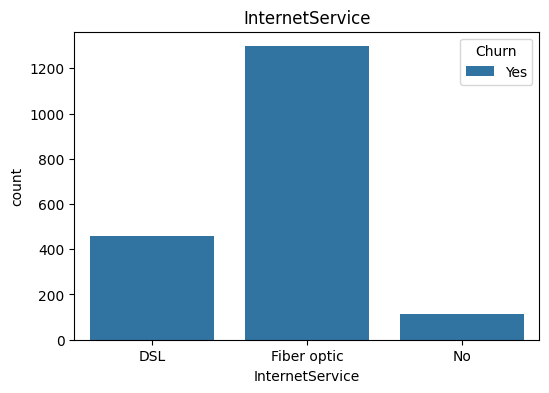

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(data=churn, x="InternetService", hue="Churn")
plt.title("InternetService")
plt.show()

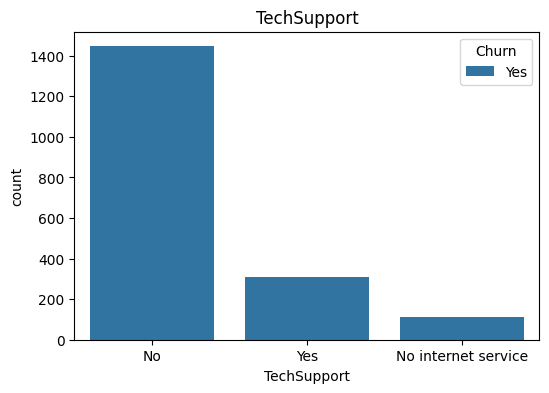

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(data=churn, x="TechSupport", hue="Churn")
plt.title("TechSupport")
plt.show()

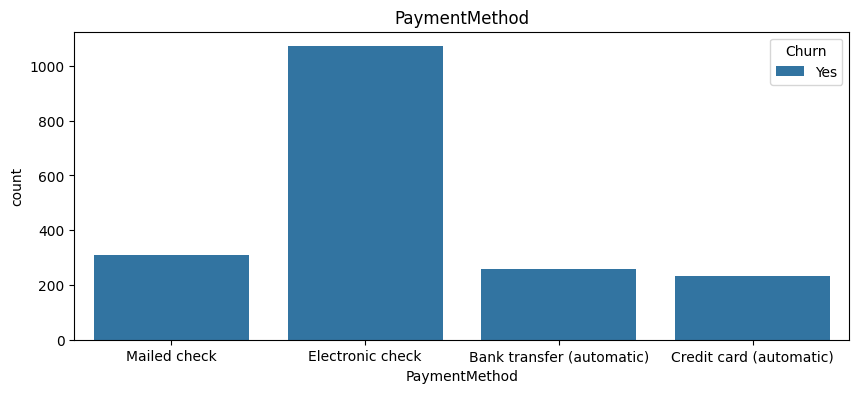

In [16]:
plt.figure(figsize=(10,4))

sns.countplot(data=churn, x="PaymentMethod", hue="Churn")
plt.title("PaymentMethod")
plt.show()

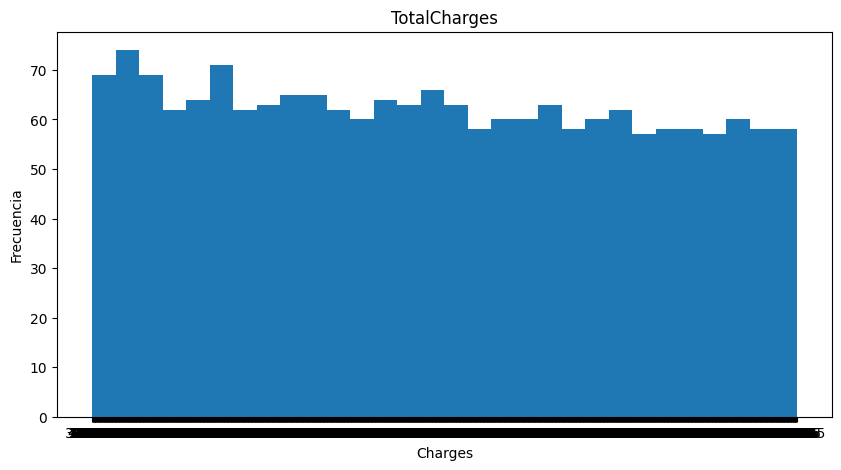

In [17]:
#Totalcharges
plt.figure(figsize=(10,5))
plt.hist(churn["TotalCharges"], bins=30)

plt.title("TotalCharges")
plt.xlabel("Charges")
plt.ylabel("Frecuencia")

plt.show()